<h1> CMBI Coursework 2 -  Part 2
<h3> Giuliano Costa

In [66]:
"""Imports"""
import numpy as np
from scipy import stats, special
from itertools import combinations
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd


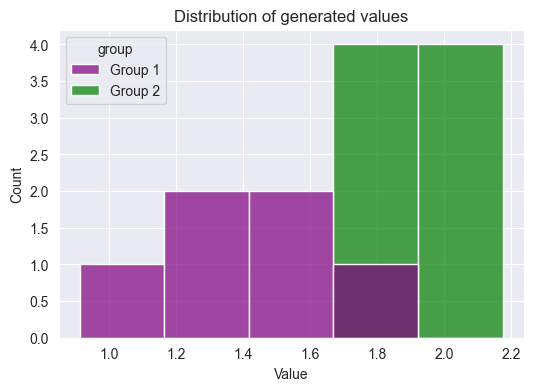

In [67]:
random_seed = 24225233

samples_1 = stats.norm.rvs(loc=1.5, scale=0.2, random_state=random_seed, size=6)
samples_2 = stats.norm.rvs(loc=2.0, scale=0.2, random_state=random_seed+1, size=8)

df = pd.DataFrame({
    'value': np.concatenate([samples_1, samples_2]),
    'group': ['Group 1'] * len(samples_1) + ['Group 2'] * len(samples_2)
})

plt.figure(figsize=(6, 4))
sns.set_style('darkgrid')
ax = sns.histplot(data=df, bins=5, x='value', hue='group', palette={'Group 1': 'purple', 'Group 2': 'green'}, alpha=0.7)
ax.set(title="Distribution of generated values", xlabel='Value', ylabel='Count')
plt.show()



# 1. Single permutation testing

## a.

In [68]:
original_t_stat, pvalue =  stats.ttest_ind(samples_1, samples_2, random_state=random_seed, equal_var=True)
print("T-statistic: %.10f" % original_t_stat)
print("p-value: %.10f" % pvalue)
print("p-value: %.2e" % pvalue)


T-statistic: -4.4696627892
p-value: 0.0007661100
p-value: 7.66e-04


## b. Permutation based p-value

### i. Construct D vector

In [69]:
D = np.concatenate([samples_1, samples_2])
print(D)

[1.41375869 1.79246329 1.44117927 0.91265544 1.20954837 1.60565228
 1.86868745 2.07823894 1.98055579 1.89140428 1.85236527 2.17485681
 1.72514909 1.94655957]


### ii.Find all valid permutations of D

In [70]:
# Generate all permutations
n_1, n_2 = 6, 8
n = n_1 + n_2
D = np.concatenate([samples_1, samples_2])

N = int(special.comb(n, n_1))
D_group_perms = np.zeros((N, n_1 + n_2))

for row, indices in enumerate(combinations(range(n), n_1)):
    group1_indices = list(indices)
    group2_indices = [i for i in range(n) if i not in group1_indices]
    
    D_group_perms[row, :n_1] = D[group1_indices]
    D_group_perms[row, n_1:] = D[group2_indices]

print(f'Total number of permutations: {N}')

Total number of permutations: 3003


### iii. Compute t-statistic for all members to construct ECDF

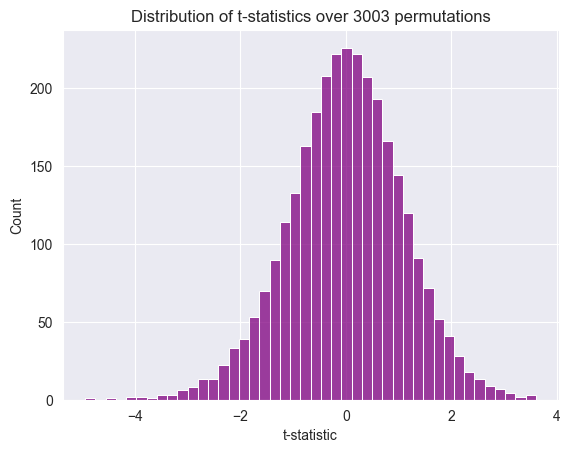

In [71]:
# Compute t-statistics for all permutations
D_t_stats = np.zeros(N)
for row in range(N):
    group1_perm = D_group_perms[row, :n_1]
    group2_perm = D_group_perms[row, n_1:]
    ttest_perm, _ = stats.ttest_ind(group1_perm, group2_perm, equal_var=True)
    D_t_stats[row] = ttest_perm

"""Construct empirical distribution for the t-statistics"""
sns.set_style('darkgrid')
ax = sns.histplot(D_t_stats, color="purple")
ax.set(title="Distribution of t-statistics over 3003 permutations", xlabel='t-statistic', ylabel='Count')
plt.show()

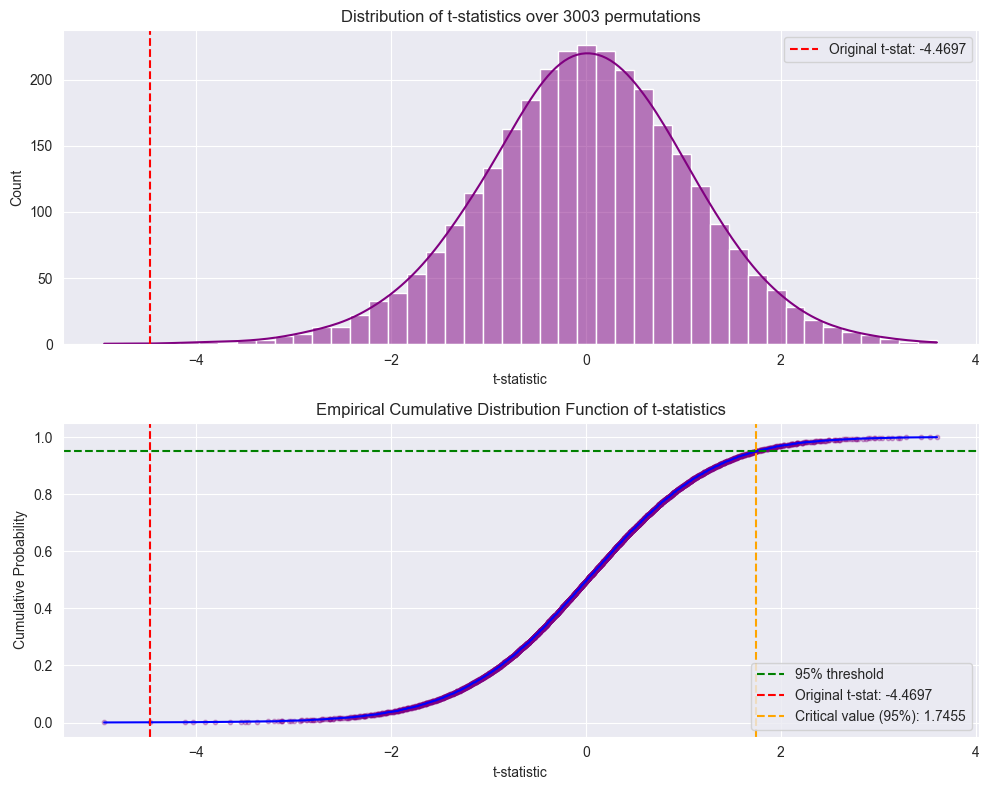

In [72]:
t_stats_sorted = np.sort(D_t_stats)

critical_index = int(0.95 * len(t_stats_sorted))
critical_value = t_stats_sorted[critical_index]
ecdf_result = stats.ecdf(D_t_stats)
x_values = np.linspace(min(D_t_stats), max(D_t_stats), 1000)

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
sns.histplot(D_t_stats, color="purple", kde=True)
plt.title("Distribution of t-statistics over 3003 permutations")
plt.xlabel('t-statistic')
plt.ylabel('Count')
plt.axvline(x=original_t_stat, color='red', linestyle='--', 
            label=f'Original t-stat: {original_t_stat:.4f}')
plt.legend()


plt.subplot(2, 1, 2)
plt.plot(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='blue', linewidth=1.5)
plt.scatter(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='purple', alpha=0.3, s=10)
plt.axhline(y=0.95, color='green', linestyle='--', 
            label='95% threshold')
plt.axvline(x=original_t_stat, color='red', linestyle='--', 
            label=f'Original t-stat: {original_t_stat:.4f}')
plt.axvline(x=critical_value, color='orange', linestyle='--', 
            label=f'Critical value (95%): {critical_value:.4f}')
plt.title("Empirical Cumulative Distribution Function of t-statistics")
plt.xlabel('t-statistic')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.tight_layout()
plt.show()


### iv. Compute p-value

In [73]:
#  TWO-sided p-value
t_stat_num_extreme = (np.abs(D_t_stats) >= np.abs(original_t_stat)).sum()
p_val_perms_correct = t_stat_num_extreme / N

print(f'original t-statistic = {original_t_stat:.3f}')
print(f'T-statistics extreme count: {t_stat_num_extreme}')
print(f't-test P-value: {pvalue:.2e},  Empirical Permutation p-val = {p_val_perms_correct:.2e}')

original t-statistic = -4.470
T-statistics extreme count: 2
t-test P-value: 7.66e-04,  Empirical Permutation p-val = 6.66e-04


## 1.c Repeat but use difference between means as test statistic

Original mean difference: -0.544
Mean differences extreme count: 2
Empirical permutation p-value (mean difference): 6.66e-04


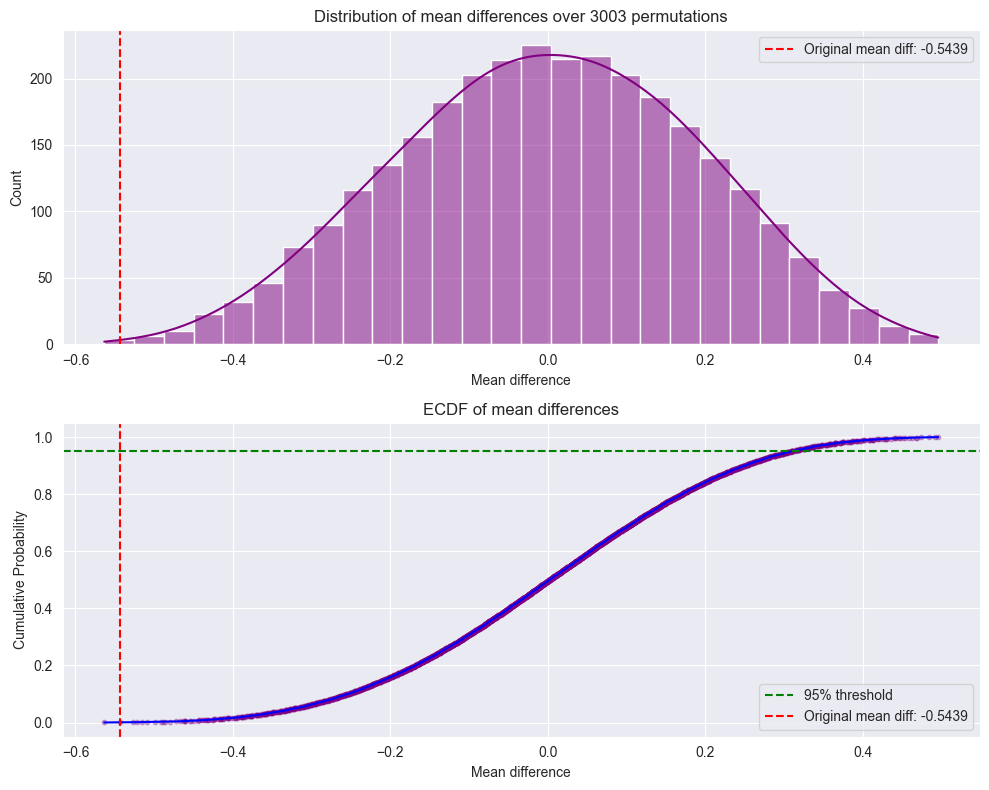

In [ ]:
original_mean_diff = np.mean(samples_1) - np.mean(samples_2)

D_mean_diffs = np.zeros(N)
for row in range(N):
    group1_perm = D_group_perms[row, :n_1]
    group2_perm = D_group_perms[row, n_1:]
    mean_diff_perm = np.mean(group1_perm) - np.mean(group2_perm)
    D_mean_diffs[row] = mean_diff_perm

# two-sided p-value
mean_diff_extreme = (np.abs(D_mean_diffs) >= np.abs(original_mean_diff)).sum()
p_val_mean_diff = mean_diff_extreme / N

print(f'Original mean difference: {original_mean_diff:.3f}')
print(f'Mean differences extreme count: {mean_diff_extreme}')
print(f'Empirical permutation p-value (mean difference): {p_val_mean_diff:.2e}')

"""DIST"""
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
sns.histplot(D_mean_diffs, color="purple", kde=True)
plt.title("Distribution of mean differences over 3003 permutations")
plt.xlabel('Mean difference')
plt.ylabel('Count')
plt.axvline(x=original_mean_diff, color='red', linestyle='--', 
            label=f'Original mean diff: {original_mean_diff:.4f}')
plt.legend()

"""ECDF"""
ecdf_result = stats.ecdf(D_mean_diffs)
plt.subplot(2, 1, 2)
plt.plot(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='blue', linewidth=1.5)
plt.scatter(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='purple', alpha=0.3, s=10)
plt.axhline(y=0.95, color='green', linestyle='--', 
            label='95% threshold')
plt.axvline(x=original_mean_diff, color='red', linestyle='--', 
            label=f'Original mean diff: {original_mean_diff:.4f}')
plt.title("ECDF of mean differences")
plt.xlabel('Mean difference')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.tight_layout()
plt.show()

## 1.d Compute approximate permutation-based p-value using 1000 random permutations.

### i. 

Duplication rate: 0.1590 (15.90%)
Original t-statistic: -4.4697 Original p-value: 7.66e-04
Number of permutations with extreme t-statistics: 1
Approximate p-value: 1.00e-03
Exact p-value from all permutations: 0.000666


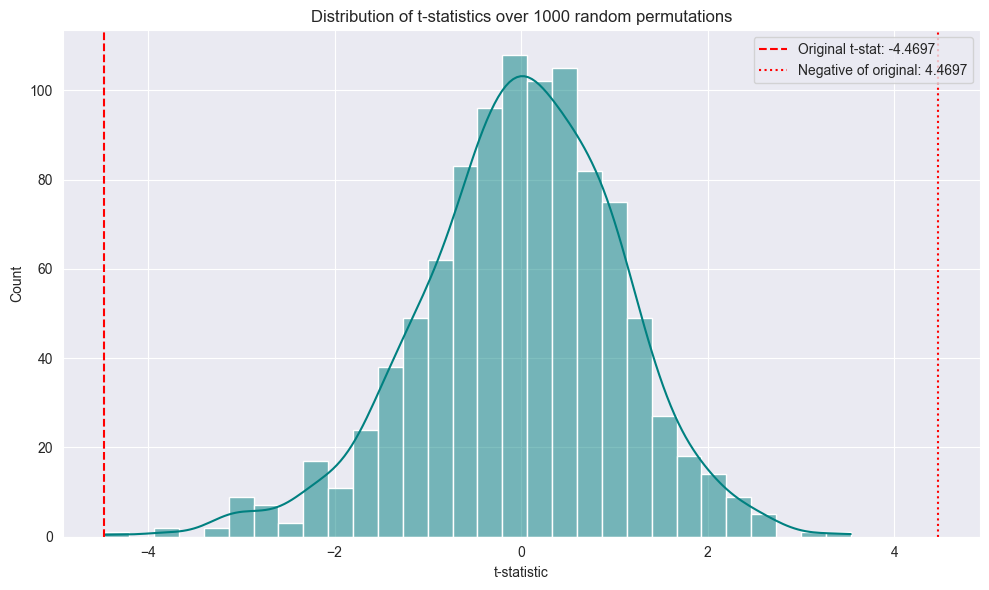

In [ ]:
original_t_stat, pvalue = stats.ttest_ind(samples_1, samples_2, equal_var=True)

num_perms = 1000
n_1, n_2 = 6, 8
n = n_1 + n_2
D = np.concatenate([samples_1, samples_2])
random_t_stats = np.zeros(num_perms)
#Include original
random_t_stats[0] = original_t_stat
perm_configurations = np.zeros((num_perms, n_1), dtype=int)
perm_configurations[0] = np.arange(n_1) 
for i in range(1, num_perms):
    perm_indices = np.random.permutation(n)
    perm_configurations[i] = np.sort(perm_indices[:n_1])
    
    group1_indices = perm_indices[:n_1]
    group2_indices = perm_indices[n_1:]
    
    values_group1 = D[group1_indices]
    values_group2 = D[group2_indices]
    
    t_stat, _ = stats.ttest_ind(values_group1, values_group2, equal_var=True)
    random_t_stats[i] = t_stat

extreme_count = (np.abs(random_t_stats) >= np.abs(original_t_stat)).sum()
p_value_approx = extreme_count / num_perms

"""DUPLICATES"""
unique_perms = np.unique(perm_configurations, axis=0)
num_unique = len(unique_perms)
num_duplicates = num_perms - num_unique
print(f"Duplication rate: {num_duplicates/num_perms:.4f} ({num_duplicates/num_perms*100:.2f}%)")

print(f"Original t-statistic: {original_t_stat:.4f} Original p-value: {pvalue:.2e}")
print(f"Number of permutations with extreme t-statistics: {extreme_count}")
print(f"Approximate p-value: {p_value_approx:.2e}")
print(f"Exact p-value from all permutations: {p_val_perms_correct:.6f}")

plt.figure(figsize=(10, 6))
sns.histplot(random_t_stats, color="teal", kde=True)
plt.axvline(x=original_t_stat, color='red', linestyle='--', 
           label=f'Original t-stat: {original_t_stat:.4f}')
plt.axvline(x=-original_t_stat, color='red', linestyle=':', 
           label=f'Negative of original: {-original_t_stat:.4f}')
plt.title("Distribution of t-statistics over 1000 random permutations")
plt.xlabel('t-statistic')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

### iii check duplicates. (above)

# 2. Single threshold test

## Load Data and plot ROI

In [76]:
def load_files(filenames):
    n = len(filenames)
    data = np.zeros(shape=(n, 40, 40, 40))
    for im_num, filename in enumerate(filenames):
        with open(filename, 'rb') as f:
            im_data = np.fromfile(f, dtype=np.float32)
            im_data = im_data.reshape((40, 40, 40))
        data[im_num] = im_data
    
    return data

In [77]:
# load all files
filename_CPA_nums = ['4', '5', '6', '7', '8', '9', '10', '11']
filename_PPA_nums = ['3', '6', '9', '10', '13', '14', '15', '16']

filenames_mask = ['./data/wm_mask.img']
filenames_CPA = ['./data/CPA' + num + '_diffeo_fa.img' for num in filename_CPA_nums]
filenames_PPA = ['./data/PPA' + num + '_diffeo_fa.img' for num in filename_PPA_nums]


data_CPA = load_files(filenames_CPA)
data_PPA = load_files(filenames_PPA)
data_mask = load_files(filenames_mask)[0,:,:,:]

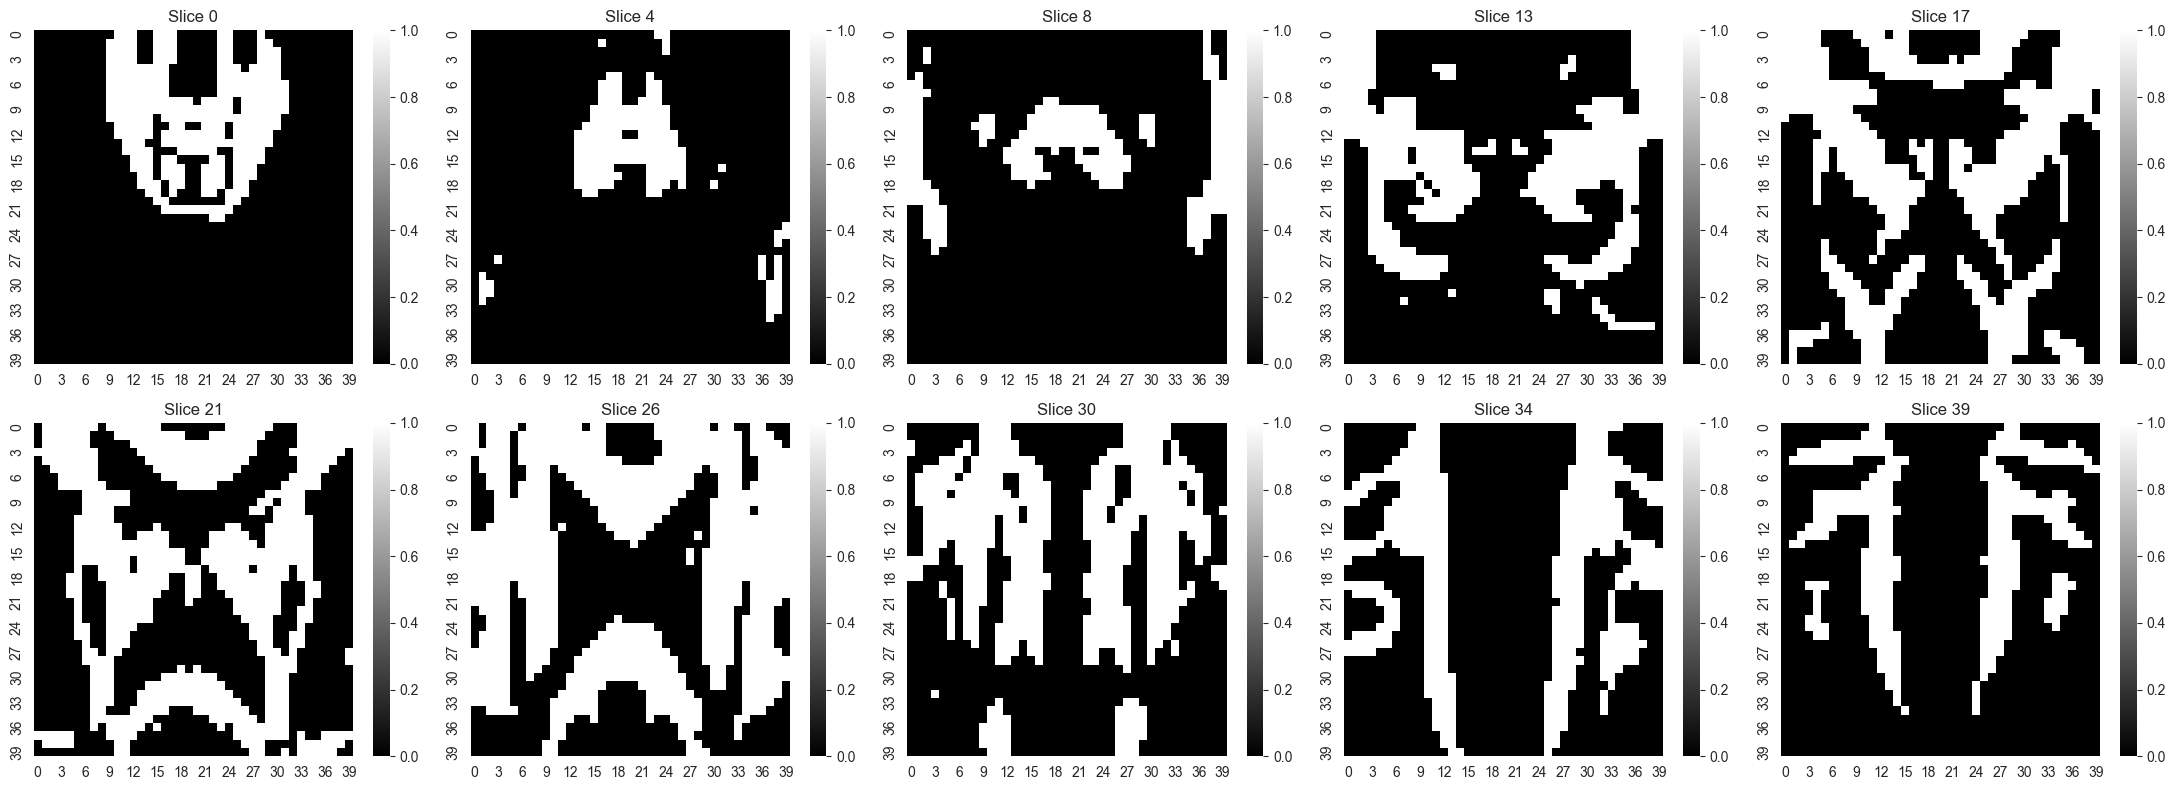

In [78]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten() 
slice_indices = np.linspace(0, 39, 10, dtype=int)

for i, idx in enumerate(slice_indices):
    sns.heatmap(data_mask[idx], 
                ax=axes[i], 
                cmap='gray')
    axes[i].set_title(f'Slice {idx}')

plt.tight_layout()
plt.show()

In [79]:
"""Compute t-statistic between the groups"""

print(data_CPA.shape)
print(data_PPA.shape)
print(data_mask.shape)

"""Note, first index in the array is the image num"""

(8, 40, 40, 40)
(8, 40, 40, 40)
(40, 40, 40)


'Note, first index in the array is the image num'

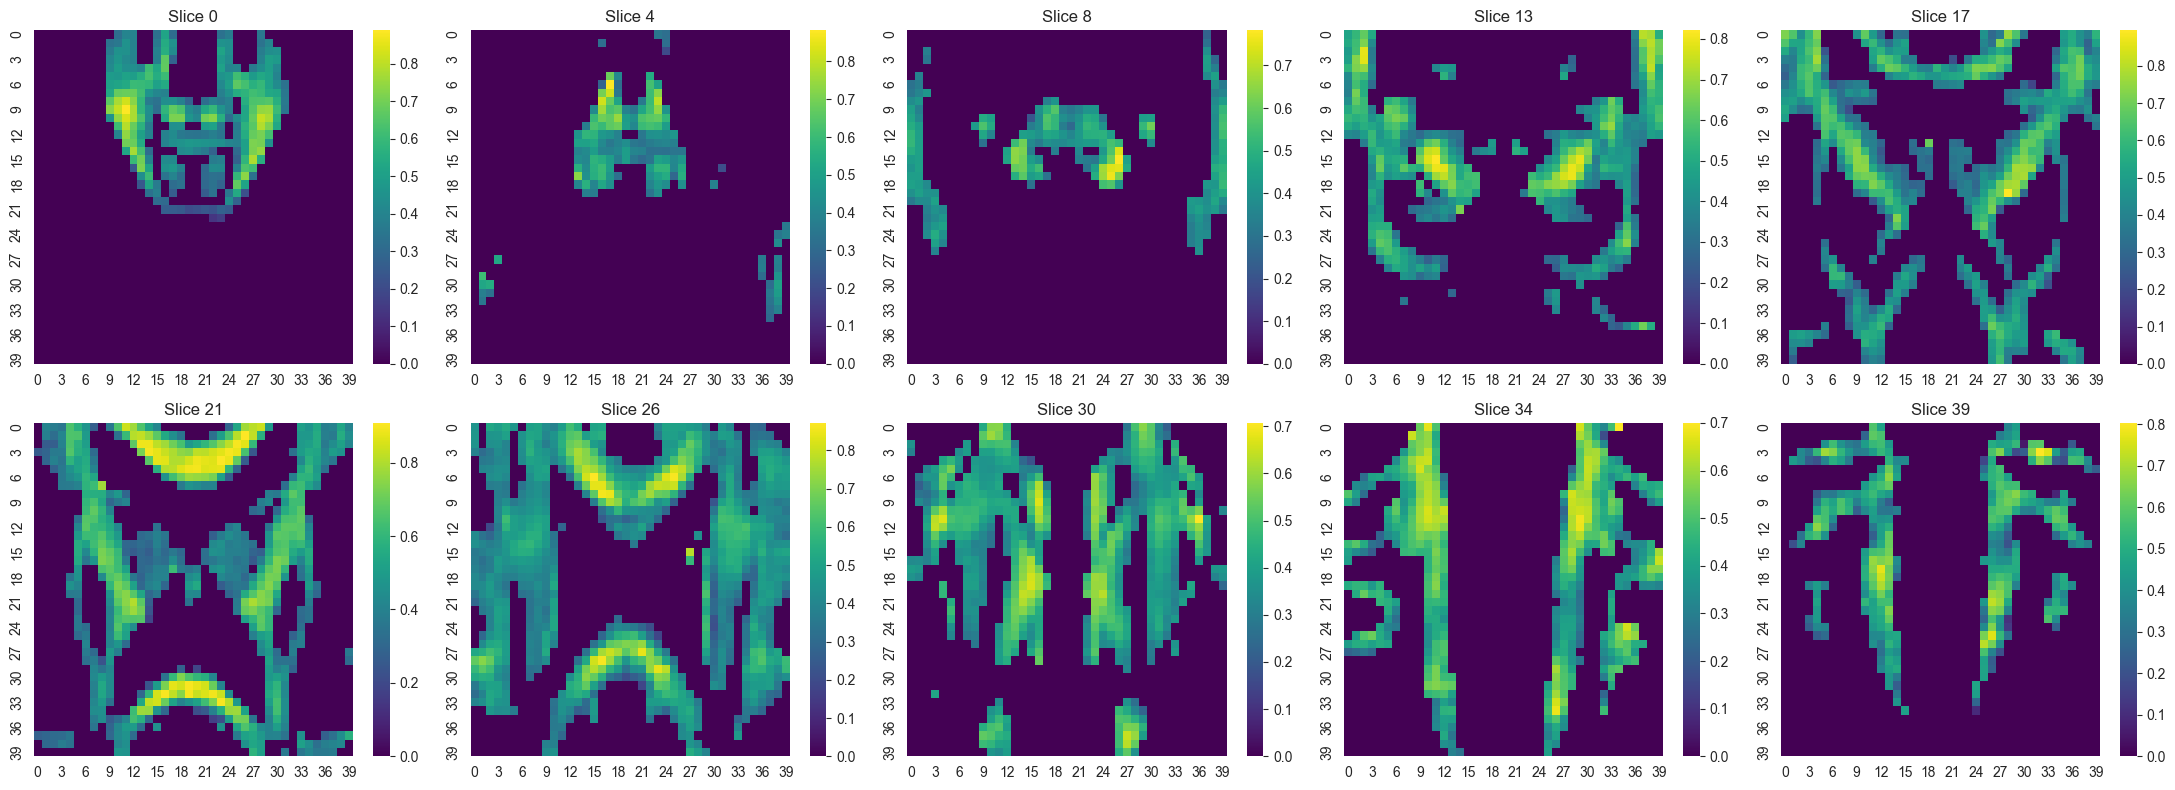

In [80]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten() 
slice_indices = np.linspace(0, 39, 10, dtype=int)


for i, idx in enumerate(slice_indices):
    im = data_CPA[0][idx]
    
    slice_ROI = data_mask[idx]
    im_masked = im.copy()
    im_masked[slice_ROI == 0] = 0 
    sns.heatmap(im_masked, 
                ax=axes[i], 
                cmap='viridis')
    axes[i].set_title(f'Slice {idx}')

plt.tight_layout()
plt.show()

## 2.a

Original maximum t-statistic: 6.5294


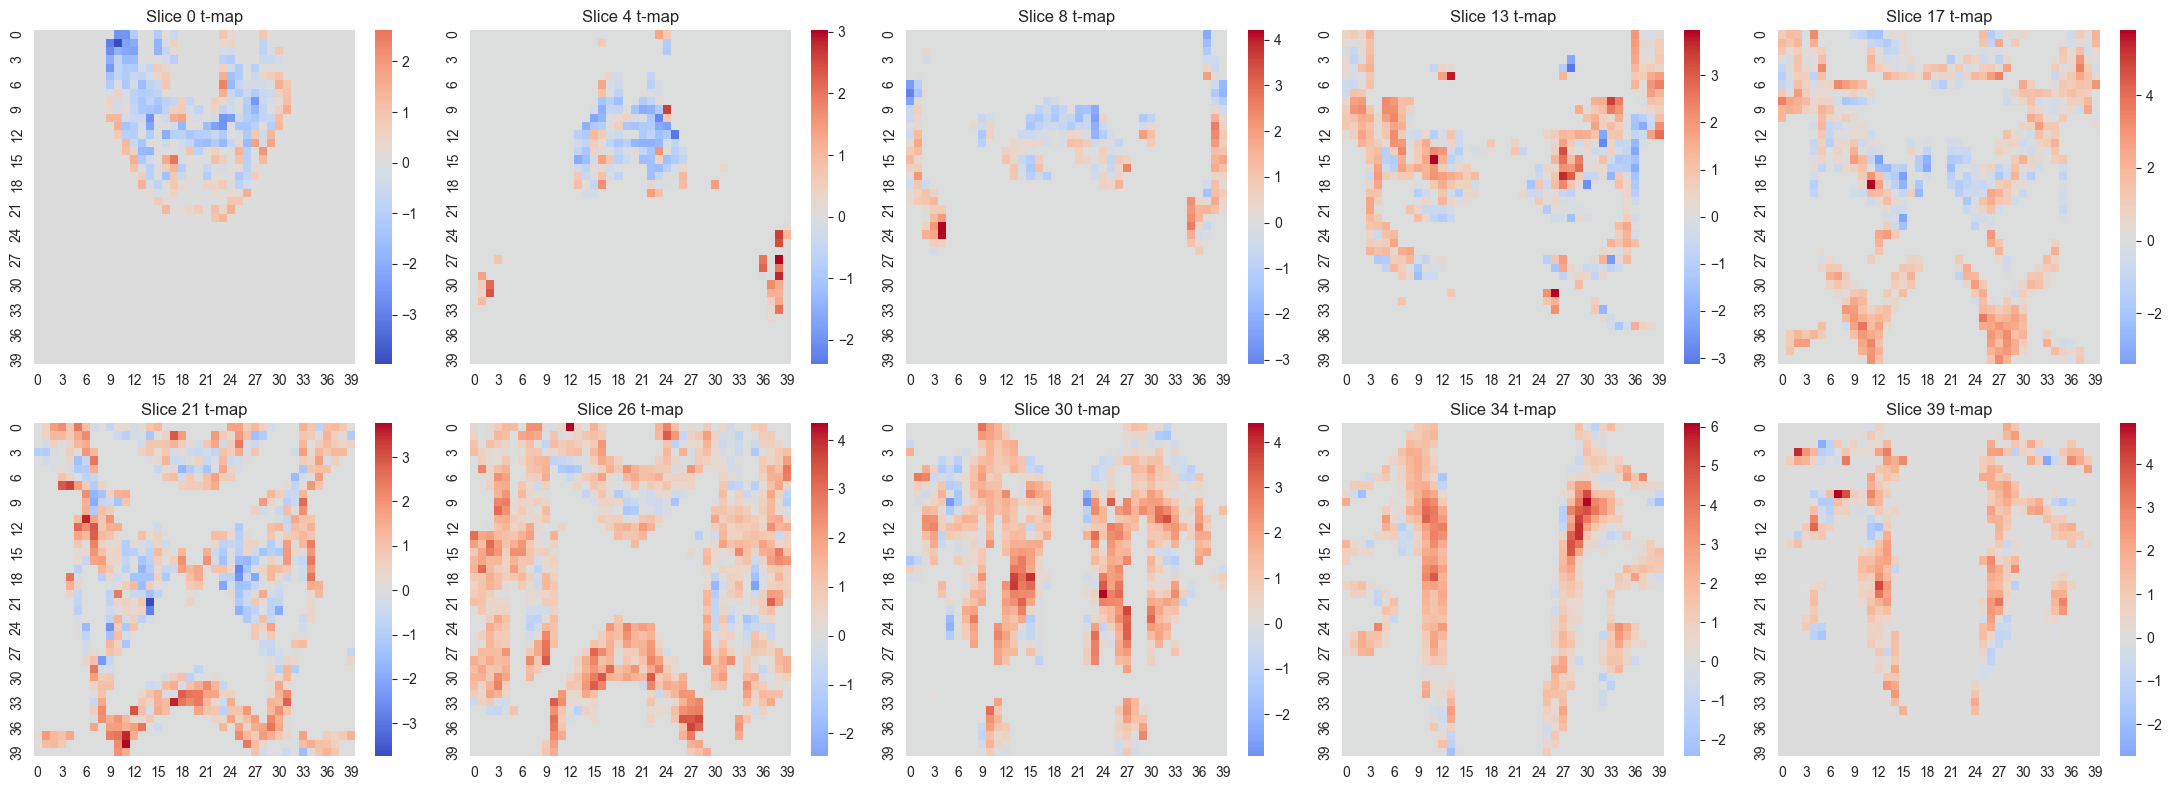

In [ ]:
"""GLM Model from part 1 where Y = X₁β₁ + X₂β₂ + e 
Essentially does ttest2.

"""
def compute_tstat_glm(group1_data, group2_data):
    Y = np.concatenate([group1_data, group2_data])
    n1 = len(group1_data)
    n2 = len(group2_data)
    X = np.zeros((n1 + n2, 2))
    X[:n1, 0] = 1  # CPA
    X[n1:, 1] = 1  # PPA 
    
    XTX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XTX_inv @ (X.T @ Y)
    
    Y_hat = X @ beta_hat
    e_hat = Y - Y_hat
    sigma_squared = (e_hat.T @ e_hat) / (n1 + n2 - 2)
    
    cov_beta = sigma_squared * XTX_inv
    
    lambda_vec = np.array([1, -1]) 
    
    lambda_beta = lambda_vec @ beta_hat
    lambda_S_lambda = lambda_vec @ cov_beta @ lambda_vec
    t_stat = lambda_beta / np.sqrt(lambda_S_lambda)
    
    return t_stat

mask_indices = np.where(data_mask > 0)
num_roi_voxels = len(mask_indices[0])
t_map = np.zeros_like(data_mask)

def compute_tmap_and_max(data1, data2, mask):
    t_map = np.zeros_like(mask, dtype=float)
    mask_indices = np.where(mask > 0)
    
    for i, j, k in zip(mask_indices[0], mask_indices[1], mask_indices[2]):
        voxel_vals_1 = data1[:, i, j, k]
        voxel_vals_2 = data2[:, i, j, k]
        
        t_stat = compute_tstat_glm(voxel_vals_1, voxel_vals_2)
        t_map[i, j, k] = t_stat
    
    max_t = np.max(t_map[mask > 0])
    return max_t, t_map

original_max_t, original_tmap = compute_tmap_and_max(data_CPA, data_PPA, data_mask)
print(f"Original maximum t-statistic: {original_max_t:.4f}")

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
slice_indices = np.linspace(0, 39, 10, dtype=int)
for i, idx in enumerate(slice_indices):
    t_slice = original_tmap[idx].copy()
    mask_slice = data_mask[idx]
    t_slice[mask_slice == 0] = 0
    
    sns.heatmap(t_slice, 
                ax=axes[i], 
                cmap='coolwarm',
                center=0) 
    axes[i].set_title(f'Slice {idx} t-map')

plt.tight_layout()
plt.show()

In [82]:
np.concatenate([data_CPA, data_PPA], axis=0).dtype

dtype('float64')

Total possible permutations: 12870
Using 12870 permutations
Starting permutation testing...
Starting permutation testing in parallel...


Processing permutations: 100%|██████████| 12870/12870 [15:28<00:00, 13.86it/s]


Permutation testing completed in 930.54 seconds
Permutation-based p-value: 0.0920


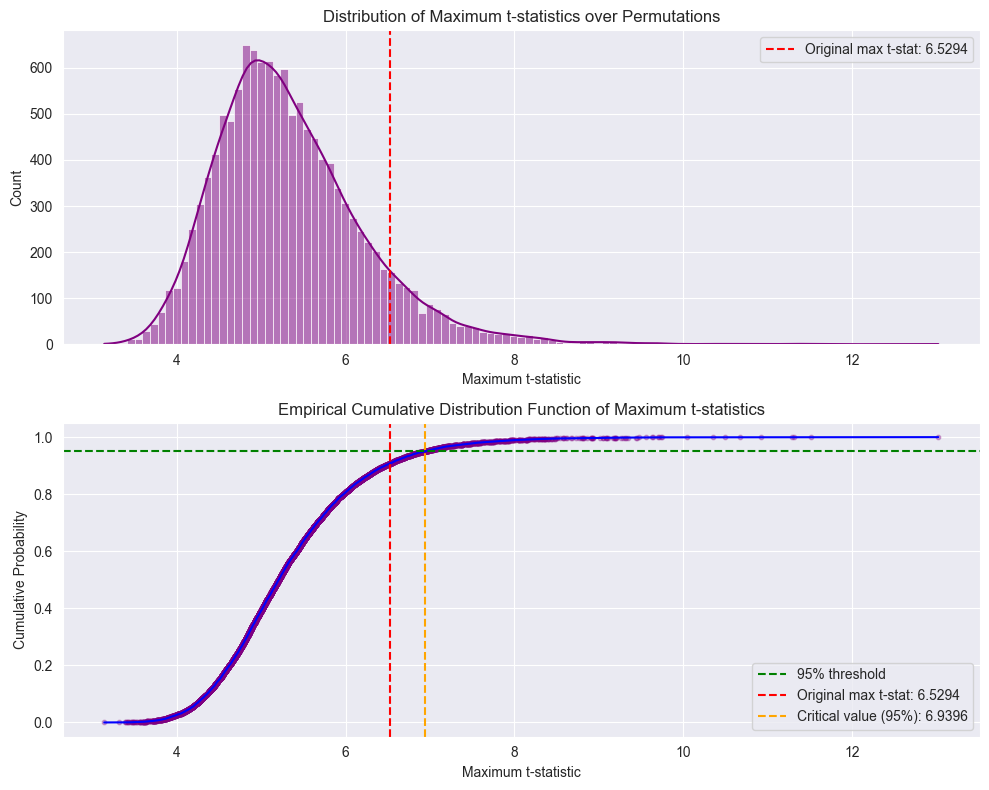

Critical threshold (95th percentile): 6.9396


In [ ]:
import time
import joblib
from tqdm import tqdm


n_CPA = data_CPA.shape[0] 
n_PPA = data_PPA.shape[0] 
n_total = n_CPA + n_PPA  

all_data = np.concatenate([data_CPA, data_PPA], axis=0)
all_data = all_data.astype(np.float16)

n_permutations = int(special.comb(n_total, n_CPA))
print(f"Total possible permutations: {n_permutations}")

max_permutations = min(n_permutations, n_permutations)  
print(f"Using {max_permutations} permutations")

all_combinations = list(combinations(range(n_total), n_CPA))

# If we're using a subset, randomly sample from all combinations
if len(all_combinations) > max_permutations:
    import random
    random.seed(24225233) 
    all_combinations = random.sample(all_combinations, max_permutations)

original_combination = tuple(range(n_CPA))
if original_combination not in all_combinations:
    all_combinations[0] = original_combination

max_t_stats = []
print("Starting permutation testing...")
start_time = time.time()
inputs = []
for combo in all_combinations:
    idx_group1 = list(combo)
    
    idx_group2 = [i for i in range(n_total) if i not in idx_group1]
    
    inputs.append((all_data[idx_group1], all_data[idx_group2], data_mask))

def compute_permutation(args):
    perm_data1, perm_data2, mask = args
    max_t, _ = compute_tmap_and_max(perm_data1, perm_data2, mask)
    return max_t

print("Starting permutation testing in parallel...")
start_time = time.time()

n_jobs = joblib.cpu_count() - 1  # Use all but one CPU 
max_t_stats = joblib.Parallel(n_jobs=n_jobs, verbose=0)(
    joblib.delayed(compute_permutation)(args) 
    for args in tqdm(inputs, desc="Processing permutations")
)

elapsed_time = time.time() - start_time
print(f"Permutation testing completed in {elapsed_time:.2f} seconds")


p_value = (np.sum(np.array(max_t_stats) >= original_max_t)) / len(max_t_stats)
print(f"Permutation-based p-value: {p_value:.4f}")

max_t_stats_sorted = np.sort(max_t_stats)

critical_index = int(0.95 * len(max_t_stats_sorted))
critical_value = max_t_stats_sorted[critical_index]

ecdf_result = stats.ecdf(max_t_stats)

plt.figure(figsize=(10, 8))
"""DIST"""
plt.subplot(2, 1, 1)
sns.histplot(max_t_stats, color="purple", kde=True)
plt.title("Distribution of Maximum t-statistics over Permutations")
plt.xlabel('Maximum t-statistic')
plt.ylabel('Count')
plt.axvline(x=original_max_t, color='red', linestyle='--', 
            label=f'Original max t-stat: {original_max_t:.4f}')
plt.legend()

"""ECDF"""
plt.subplot(2, 1, 2)
plt.plot(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='blue', linewidth=1.5)
plt.scatter(ecdf_result.cdf.quantiles, ecdf_result.cdf.probabilities, color='purple', alpha=0.3, s=10)
plt.axhline(y=0.95, color='green', linestyle='--', 
            label='95% threshold')
plt.axvline(x=original_max_t, color='red', linestyle='--', 
            label=f'Original max t-stat: {original_max_t:.4f}')
plt.axvline(x=critical_value, color='orange', linestyle='--', 
            label=f'Critical value (95%): {critical_value:.4f}')
plt.title("Empirical Cumulative Distribution Function of Maximum t-statistics")
plt.xlabel('Maximum t-statistic')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.tight_layout()
plt.show()

# Print the critical threshold value
print(f"Critical threshold (95th percentile): {critical_value:.4f}")